#*Fetal Vein Segmentation*



Install the required packages

In [ ]:
#import data from google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# install the latest weekly preview version of MONAI
%pip install -q "monai-weekly[tqdm, nibabel, gdown, ignite]"
%pip install -q torcheval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 7.9 MB/s eta 0:00:00


Setup imports

In [ ]:
import os
import shutil
import tempfile
import time
import matplotlib.pyplot as plt
from monai.config import print_config
from monai.data import DataLoader, decollate_batch
from monai.handlers.utils import from_engine
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.networks.nets import UNet
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch, list_data_collate
from monai.transforms import (
    Activations,
    Activationsd,
    AsDiscrete,
    AsDiscreted,
    Compose,
    Invertd,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    Spacingd,
    EnsureTyped,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    SpatialPadd,
)
from monai.utils import set_determinism
import glob
import torch
import pdb
from torcheval.metrics.functional import binary_f1_score
from PIL import Image

print_config()

MONAI version: 1.6.dev2616
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: deeaf7ed63fe2d2d48b639406f0f1611c58d3416
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://monai.readthedocs.io/en/latest/installat

Set deterministic training for reproducibility

In [ ]:
set_determinism(seed=0)

Setup transforms for training, validation, and testing

In [ ]:
train_transform = Compose(
    [
        LoadImaged(keys=["image", "label"], image_only=False),
        EnsureChannelFirstd(keys=["image", "label"]),
        ScaleIntensityRanged(
            keys=["image","label"], a_min=0, a_max=255,
            b_min=0.0, b_max=1.0, clip=True,
        ),
    ]
)

val_transform = Compose(
    [
        LoadImaged(keys=["image", "label"], image_only=False),
        EnsureChannelFirstd(keys=["image", "label"]),
        ScaleIntensityRanged(
            keys=["image","label"], a_min=0, a_max=255,
            b_min=0.0, b_max=1.0, clip=True,
        ),
    ]
)

test_transform = Compose(
    [
        LoadImaged(keys=["image", "label"], image_only=False),
        EnsureChannelFirstd(keys=["image", "label"]),
        ScaleIntensityRanged(
            keys=["image","label"], a_min=0, a_max=255,
            b_min=0.0, b_max=1.0, clip=True,
        ),
    ]
)

Create Datasets

In [ ]:
# dataset
data_dir = "/content/drive/MyDrive/Dataset"
images = sorted(glob.glob(os.path.join(data_dir, "images", "*.png")))
gt = sorted(glob.glob(os.path.join(data_dir, "labels", "*.png")))
data_dicts  = [
    {"image": image_name, "label": gt_name}
    for image_name, gt_name in zip(images, gt)
]
train_files = data_dicts[:110]
val_files = data_dicts[110:130]
test_files = data_dicts[130:]

In [ ]:
test_files

[{'image': '/content/drive/MyDrive/Dataset/images/P080_IMG1.png',
  'label': '/content/drive/MyDrive/Dataset/labels/P080_IMG1.png'},
 {'image': '/content/drive/MyDrive/Dataset/images/P081_IMG1.png',
  'label': '/content/drive/MyDrive/Dataset/labels/P081_IMG1.png'},
 {'image': '/content/drive/MyDrive/Dataset/images/P082_IMG1.png',
  'label': '/content/drive/MyDrive/Dataset/labels/P082_IMG1.png'},
 {'image': '/content/drive/MyDrive/Dataset/images/P083_IMG1.png',
  'label': '/content/drive/MyDrive/Dataset/labels/P083_IMG1.png'},
 {'image': '/content/drive/MyDrive/Dataset/images/P084_IMG1.png',
  'label': '/content/drive/MyDrive/Dataset/labels/P084_IMG1.png'},
 {'image': '/content/drive/MyDrive/Dataset/images/P085_IMG1.png',
  'label': '/content/drive/MyDrive/Dataset/labels/P085_IMG1.png'},
 {'image': '/content/drive/MyDrive/Dataset/images/P086_IMG1.png',
  'label': '/content/drive/MyDrive/Dataset/labels/P086_IMG1.png'},
 {'image': '/content/drive/MyDrive/Dataset/images/P087_IMG1.png',
  '

In [ ]:
train_ds = Dataset(data=train_files, transform=train_transform)
train_loader = DataLoader(train_ds, batch_size=10, shuffle=True, num_workers=0, collate_fn=list_data_collate)

val_ds = Dataset(data=val_files, transform=val_transform)
val_loader = DataLoader(val_ds, batch_size=5, shuffle=False, num_workers=0, collate_fn=list_data_collate)

test_ds = Dataset(data=test_files, transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0, collate_fn=list_data_collate)

Check Data

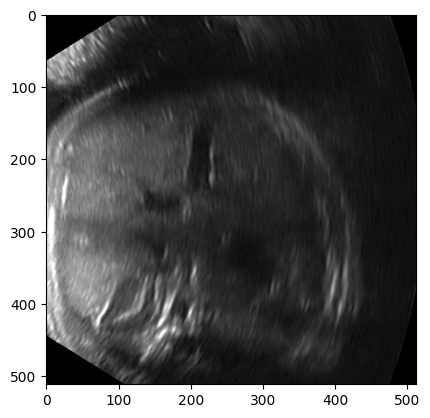

In [ ]:
val_data_example = val_ds[0]
plt.imshow(val_data_example["image"][0,:,:], cmap = 'gray')

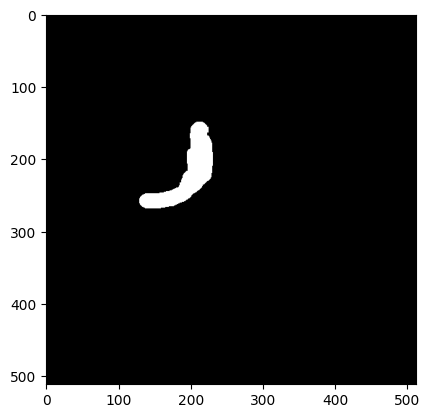

In [ ]:
plt.imshow(val_data_example["label"][0,:,:], cmap = 'gray')

Layers, blocks, networks and loss functions

In [ ]:
max_epochs = 150
val_interval = 1
VAL_AMP = True

#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).cuda()

loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-2)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

dice_metric = DiceMetric(include_background=True, reduction="mean")
dice_metric_batch = DiceMetric(include_background=True, reduction="mean_batch")

post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

Execute a typical PyTorch training process

In [ ]:
best_metric = -1
best_metric_epoch = -1
best_metrics_epochs_and_time = [[], [], []]
epoch_loss_values = []
val_values = []

total_start = time.time()

for epoch in range(max_epochs):
    epoch_start = time.time()
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step_start = time.time()
        step += 1
        inputs, labels = (
            batch_data["image"].cuda(),
            batch_data["label"].cuda(),
        )

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        print(
            f"{step}/{len(train_ds) // train_loader.batch_size}"
            f", train_loss: {loss.item():.4f}"
            f", step time: {(time.time() - step_start):.4f}"
        )

    lr_scheduler.step()

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)

    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data["image"].cuda(),
                    val_data["label"].cuda(),
                )
                val_outputs = model(val_inputs)

                loss_val = loss_function(val_outputs, val_labels)

                val_outputs = (torch.sigmoid(val_outputs))
                val_outputs = val_outputs > 0.5

                dice_metric(y_pred=val_outputs, y=val_labels)
                dice_metric_batch(y_pred=val_outputs, y=val_labels)

            metric = dice_metric.aggregate().item()
            val_values.append(loss_val)
            metric_batch = dice_metric_batch.aggregate()

            dice_metric.reset()
            dice_metric_batch.reset()

            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                best_metrics_epochs_and_time[0].append(best_metric)
                best_metrics_epochs_and_time[1].append(best_metric_epoch)
                best_metrics_epochs_and_time[2].append(time.time() - total_start)
                torch.save(model.state_dict(),os.path.join('drive/MyDrive/Save_Models', "best_metric_model.pth"))
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f"\nbest mean dice: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
    print(f"time consuming of epoch {epoch + 1} is: {(time.time() - epoch_start):.4f}")
    torch.save(model.state_dict(),os.path.join('drive/MyDrive/Save_Models', "last_metric_last.pth"))
total_time = time.time() - total_start

----------
epoch 1/150
1/11, train_loss: 0.9461, step time: 0.2198
2/11, train_loss: 0.9408, step time: 0.2312
3/11, train_loss: 0.9390, step time: 0.2215
4/11, train_loss: 0.9447, step time: 0.2047
5/11, train_loss: 0.9244, step time: 0.2283
6/11, train_loss: 0.9461, step time: 0.2292
7/11, train_loss: 0.9272, step time: 0.2164
8/11, train_loss: 0.9305, step time: 0.2028
9/11, train_loss: 0.9319, step time: 0.2209
10/11, train_loss: 0.9291, step time: 0.2136
11/11, train_loss: 0.9200, step time: 0.2128
epoch 1 average loss: 0.9345
saved new best metric model
current epoch: 1 current mean dice: 0.0700
best mean dice: 0.0700 at epoch: 1
time consuming of epoch 1 is: 70.5034
----------
epoch 2/150
1/11, train_loss: 0.9194, step time: 0.2027
2/11, train_loss: 0.9249, step time: 0.1582
3/11, train_loss: 0.9339, step time: 0.1365
4/11, train_loss: 0.9167, step time: 0.1382
5/11, train_loss: 0.9031, step time: 0.1390
6/11, train_loss: 0.9176, step time: 0.1381
7/11, train_loss: 0.9160, step 

Plot the learning curves

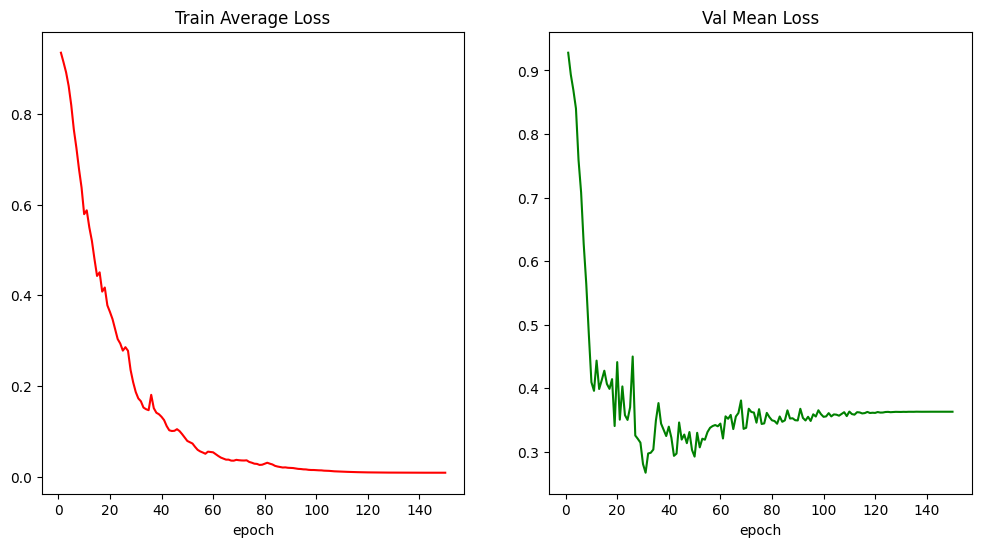

In [ ]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y, color="red")
plt.subplot(1, 2, 2)
plt.title("Val Mean Loss")
val_values = [t.to('cpu') for t in val_values]
x = [val_interval * (i + 1) for i in range(len(val_values))]
y = val_values
plt.xlabel("epoch")
plt.plot(x, y, color="green")
plt.show()

Evaluate the method in the testing set

In [ ]:
import cv2

threshold = 0.5

list_imgs = []
list_nm = []
list_labels = []
list_predicted = []

model.load_state_dict(torch.load(os.path.join('drive/MyDrive/Save_Models', "best_metric_model.pth")))
model.eval()
with torch.no_grad():
  for test_data in test_loader:


    test_inputs, test_labels,name_img = (
        test_data["image"].cuda(),
        test_data["label"].cuda(),
        test_data["image_meta_dict"],
    )
    test_outputs = model(test_inputs)
    test_outputs = (torch.sigmoid(test_outputs))
    test_outputs = test_outputs > threshold

    seg = test_outputs[0,0,:,:].cpu().numpy()
    gt = test_labels[0,0,:,:].cpu().numpy()

    list_predicted.append(seg)
    list_labels.append(gt)
    list_imgs.append(test_inputs[0,0,:,:].cpu().numpy())

    name_img = name_img['filename_or_obj'][0].replace("images","results")
    seg = (seg * 255).astype("uint8")
    image = Image.fromarray(seg)
    image.save(os.path.join(data_dir, name_img))

Visualize the results for one image

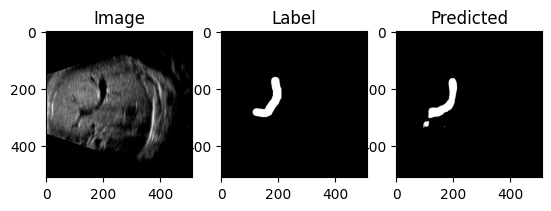

In [ ]:
plt.subplot(1, 3, 1)
plt.title("Image")
plt.imshow(list_imgs[9][:,:], cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Label")
plt.imshow(list_labels[9][:,:], cmap="gray")

plt.subplot(1, 3, 3)
plt.title("Predicted")
plt.imshow(list_predicted[9][:,:], cmap="gray")
